# EDA — Comprensión y análisis de los datos (Fase 2 CRISP-DM)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

CSV_PATH = "../datasets/statsbomb_events.csv.gz"
df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Filas:    {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Partidos: {df['match_id'].nunique():,}")

Filas:    12,188,949
Columnas: 28
Partidos: 3,464


## 1. Estructura del dataset

In [2]:
df.head(3)

,match_id,competition_name,season_name,home_team,away_team,period,minute,second,team_name,is_home,event_type,play_pattern,loc_x,loc_y,xg,shot_outcome,pass_outcome,pass_length,pass_angle,dribble_outcome,carry_length,duel_type,duel_outcome,interception_outcome,card_type,final_result,final_score_home,final_score_away
0,3895302,1. Bundesliga,2023/2024,Bayer Leverkusen,Werder Bremen,1,0,0,Bayer Leverkusen,True,Starting XI,Regular Play,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home_win,5,0
1,3895302,1. Bundesliga,2023/2024,Bayer Leverkusen,Werder Bremen,1,0,0,Werder Bremen,False,Starting XI,Regular Play,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home_win,5,0
2,3895302,1. Bundesliga,2023/2024,Bayer Leverkusen,Werder Bremen,1,0,0,Bayer Leverkusen,True,Half Start,Regular Play,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home_win,5,0


In [3]:
df.dtypes.to_frame("dtype")

,dtype
match_id,int64
competition_name,str
season_name,str
home_team,str
away_team,str
period,int64
minute,int64
second,int64
team_name,str
is_home,bool


In [4]:
df.describe(include="all")

,match_id,competition_name,season_name,home_team,away_team,period,minute,second,team_name,is_home,event_type,play_pattern,loc_x,loc_y,xg,shot_outcome,pass_outcome,pass_length,pass_angle,dribble_outcome,carry_length,duel_type,duel_outcome,interception_outcome,card_type,final_result,final_score_home,final_score_away
count,1.218895e+07,12188949,12188949,12188949,12188949,1.218895e+07,1.218895e+07,1.218895e+07,12188949,12188949,12188949,12188949,1.209711e+07,1.209711e+07,88023.000000,88023,3387760,3.387760e+06,3.387760e+06,122047,2.632570e+06,257861,134238,79641,14111,12188949,1.218895e+07,1.218895e+07
unique,NaN,21,48,299,298,NaN,NaN,NaN,308,2,35,9,NaN,NaN,NaN,8,6,NaN,NaN,2,NaN,2,5,5,3,3,NaN,NaN
top,NaN,La Liga,2015/2016,Barcelona,Barcelona,NaN,NaN,NaN,Barcelona,True,Pass,Regular Play,NaN,NaN,NaN,Off T,Complete,NaN,NaN,Complete,NaN,Tackle,Success In Play,Won,Yellow Card,home_win,NaN,NaN
freq,NaN,3136483,6396046,1019720,979189,NaN,NaN,NaN,1244016,6213669,3387760,5401529,NaN,NaN,NaN,28466,2633436,NaN,NaN,69747,NaN,134238,43536,31368,13411,5530079,NaN,NaN
mean,2.964215e+06,NaN,NaN,NaN,NaN,1.503052e+00,4.510836e+01,2.928370e+01,NaN,NaN,NaN,NaN,5.893037e+01,4.000876e+01,0.106599,NaN,NaN,2.141978e+01,9.436901e-03,NaN,5.814468e+00,NaN,NaN,NaN,NaN,NaN,1.607262e+00,1.260623e+00
std,1.565414e+06,NaN,NaN,NaN,NaN,5.177759e-01,2.725420e+01,1.738064e+01,NaN,NaN,NaN,NaN,2.855160e+01,2.330131e+01,0.149922,NaN,NaN,1.470064e+01,1.524517e+00,NaN,7.077328e+00,NaN,NaN,NaN,NaN,NaN,1.466834e+00,1.271144e+00
min,7.298000e+03,NaN,NaN,NaN,NaN,1.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,1.000000e-01,1.000000e-01,0.000180,NaN,NaN,0.000000e+00,-3.138768e+00,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00
25%,3.749108e+06,NaN,NaN,NaN,NaN,1.000000e+00,2.100000e+01,1.400000e+01,NaN,NaN,NaN,NaN,3.800000e+01,1.980000e+01,0.027747,NaN,NaN,1.133578e+01,-1.145964e+00,NaN,1.100000e+00,NaN,NaN,NaN,NaN,NaN,1.000000e+00,0.000000e+00
50%,3.825673e+06,NaN,NaN,NaN,NaN,1.000000e+00,4.500000e+01,2.900000e+01,NaN,NaN,NaN,NaN,5.820000e+01,4.000000e+01,0.054884,NaN,NaN,1.732772e+01,0.000000e+00,NaN,3.452535e+00,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e+00
75%,3.879875e+06,NaN,NaN,NaN,NaN,2.000000e+00,6.800000e+01,4.400000e+01,NaN,NaN,NaN,NaN,8.010000e+01,6.030000e+01,0.110167,NaN,NaN,2.701851e+01,1.176005e+00,NaN,7.854935e+00,NaN,NaN,NaN,NaN,NaN,2.000000e+00,2.000000e+00


In [5]:
events_per_match = df.groupby("match_id").size()
pd.DataFrame({
    "Métrica": ["Media", "Mínimo", "Máximo"],
    "Eventos por partido": [
        round(events_per_match.mean()),
        events_per_match.min(),
        events_per_match.max()
    ]
}).set_index("Métrica")

,Eventos por partido
Métrica,
Media,3519
Mínimo,2101
Máximo,5190


## 2. Tipos de evento

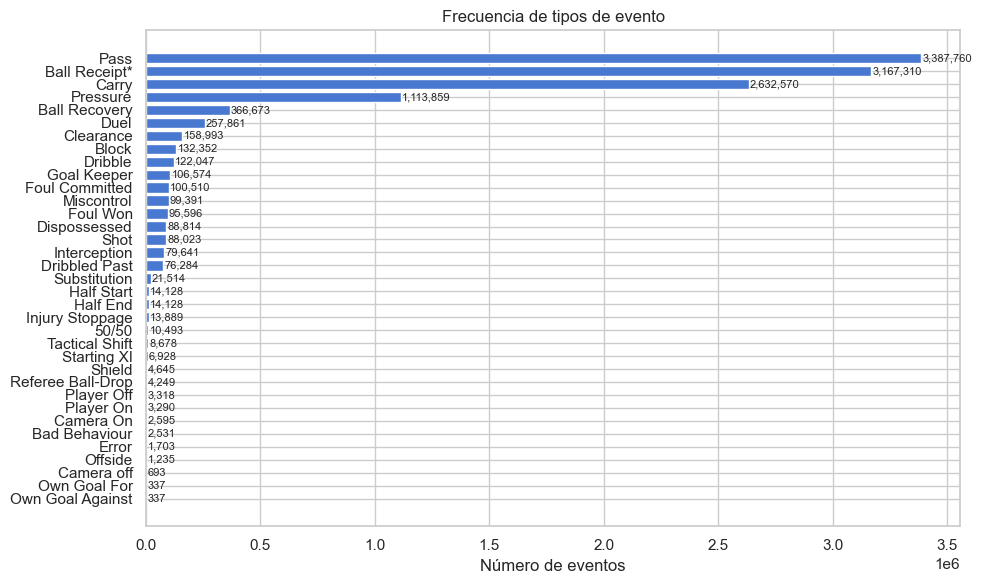

Total tipos de evento: 35


In [6]:
event_counts = df["event_type"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(event_counts.index[::-1], event_counts.values[::-1])
ax.set_title("Frecuencia de tipos de evento")
ax.set_xlabel("Número de eventos")
for i, v in enumerate(event_counts.values[::-1]):
    ax.text(v + 5000, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Total tipos de evento: {len(event_counts)}")


In [7]:
top10 = df["event_type"].value_counts().head(10).to_frame("eventos")
top10["% del total"] = (top10["eventos"] / len(df) * 100).round(1)
top10

,eventos,% del total
event_type,,
Pass,3387760,27.8
Ball Receipt*,3167310,26.0
Carry,2632570,21.6
Pressure,1113859,9.1
Ball Recovery,366673,3.0
Duel,257861,2.1
Clearance,158993,1.3
Block,132352,1.1
Dribble,122047,1.0


## 3. Balance de clases

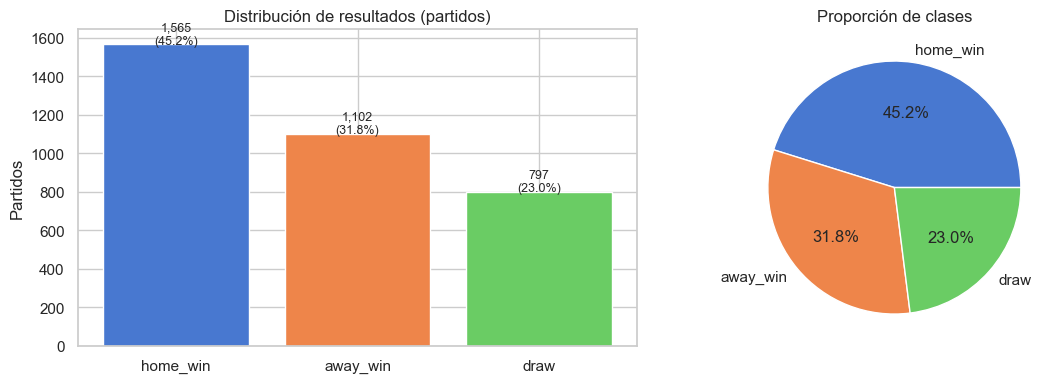

Ratio desequilibrio (max/min): 1.96


In [8]:
matches = df.drop_duplicates("match_id")[["match_id", "final_result", "competition_name"]]
result_counts = matches["final_result"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(result_counts.index, result_counts.values, color=sns.color_palette("muted", 3))
axes[0].set_title("Distribución de resultados (partidos)")
axes[0].set_ylabel("Partidos")
for i, v in enumerate(result_counts.values):
    axes[0].text(i, v + 5, f"{v:,}\n({v/result_counts.sum()*100:.1f}%)", ha="center", fontsize=9)

axes[1].pie(result_counts.values, labels=result_counts.index,
            autopct="%1.1f%%", colors=sns.color_palette("muted", 3))
axes[1].set_title("Proporción de clases")

plt.tight_layout()
plt.savefig("../assets/figuras/eda/balance_clases.pdf", bbox_inches="tight")
plt.show()

print("Ratio desequilibrio (max/min):", round(result_counts.max() / result_counts.min(), 2))


,Partidos,Victoria local,Empate,Victoria visitante
Género,,,,
Masculino,2924,"1,310 (44.8%)",707 (24.2%),907 (31.0%)
Femenino,540,255 (47.2%),90 (16.7%),195 (36.1%)


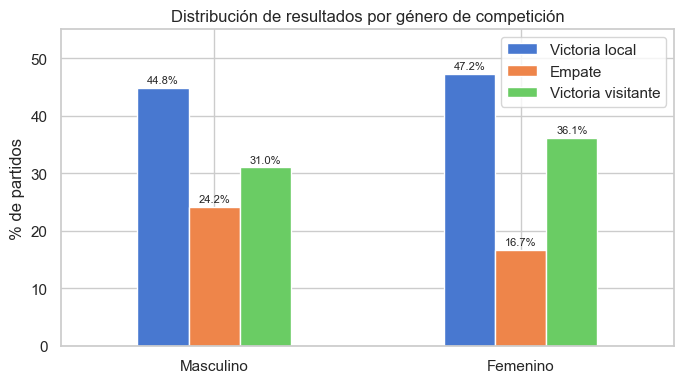

In [9]:
# Desglose por género de competición
womens_kw = ["Women", "Female", "NWSL", "WSL"]
matches_g = df.drop_duplicates("match_id")[["match_id", "competition_name", "final_result"]].copy()
matches_g["genero"] = matches_g["competition_name"].str.contains("|".join(womens_kw), case=False).map({False: "Masculino", True: "Femenino"})

rows = []
for genero in ["Masculino", "Femenino"]:
    sub = matches_g[matches_g["genero"] == genero]["final_result"].value_counts()
    total = sub.sum()
    rows.append({
        "Género": genero,
        "Partidos": total,
        "Victoria local": f"{sub.get('home_win', 0):,} ({sub.get('home_win', 0)/total*100:.1f}%)",
        "Empate":         f"{sub.get('draw', 0):,} ({sub.get('draw', 0)/total*100:.1f}%)",
        "Victoria visitante": f"{sub.get('away_win', 0):,} ({sub.get('away_win', 0)/total*100:.1f}%)",
    })

import pandas as pd
tabla_genero = pd.DataFrame(rows).set_index("Género")
display(tabla_genero)

# Gráfico comparativo
pct_data = {}
for genero in ["Masculino", "Femenino"]:
    sub = matches_g[matches_g["genero"] == genero]["final_result"].value_counts(normalize=True).mul(100)
    pct_data[genero] = sub

pct_df = pd.DataFrame(pct_data).T[["home_win", "draw", "away_win"]]
pct_df.columns = ["Victoria local", "Empate", "Victoria visitante"]

ax = pct_df.plot(kind="bar", figsize=(7, 4), rot=0, color=sns.color_palette("muted", 3))
ax.set_ylabel("% de partidos")
ax.set_title("Distribución de resultados por género de competición")
ax.set_ylim(0, 55)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../assets/figuras/eda/balance_genero.pdf", bbox_inches="tight")
plt.show()


## 4. Análisis temporal

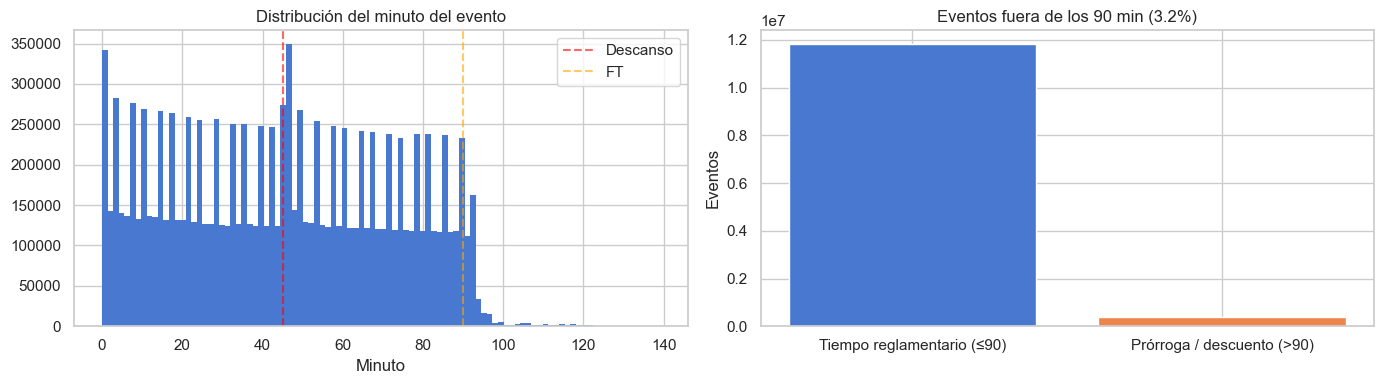

Max minuto registrado: 139
Partidos con eventos en minuto > 90: 3354 de 3464


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["minute"].dropna(), bins=100, edgecolor="none")
axes[0].axvline(45, color="red", linestyle="--", alpha=0.6, label="Descanso")
axes[0].axvline(90, color="orange", linestyle="--", alpha=0.6, label="FT")
axes[0].set_title("Distribución del minuto del evento")
axes[0].set_xlabel("Minuto")
axes[0].legend()

extra_time = df[df["minute"] > 90]
pct_extra = len(extra_time) / len(df) * 100
axes[1].bar(["Tiempo reglamentario (≤90)", "Prórroga / descuento (>90)"],
            [len(df) - len(extra_time), len(extra_time)],
            color=sns.color_palette("muted", 2))
axes[1].set_title(f"Eventos fuera de los 90 min ({pct_extra:.1f}%)")
axes[1].set_ylabel("Eventos")

plt.tight_layout()
plt.show()

print(f"Max minuto registrado: {int(df["minute"].max())}")
total_matches = df["match_id"].nunique()
matches_extra = df[df["minute"] > 90]["match_id"].nunique()
print(f"Partidos con eventos en minuto > 90: {matches_extra} de {total_matches}")

### 4b. Distribución temporal de goles

Saber en qué minutos se marcan los goles valida que la dimensión temporal es informativa y ayuda a entender en qué momentos del partido la predicción será más difícil.

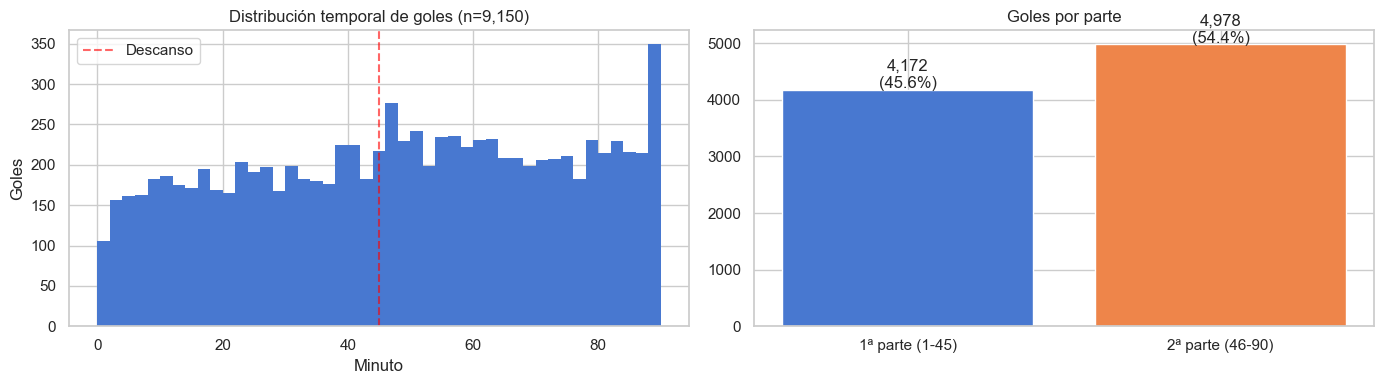

Goles totales (min ≤ 90): 9,150
Goles por partido de media: 2.64

Minuto con más goles: 47 (143 goles)


In [11]:
goals = df[(df["event_type"] == "Shot") & (df["shot_outcome"] == "Goal") & (df["minute"] <= 90)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(goals["minute"], bins=45, range=(0, 90), edgecolor="none")
axes[0].axvline(45, color="red", linestyle="--", alpha=0.6, label="Descanso")
axes[0].set_title(f"Distribución temporal de goles (n={len(goals):,})")
axes[0].set_xlabel("Minuto")
axes[0].set_ylabel("Goles")
axes[0].legend()

goals_by_half = goals.groupby(goals["minute"].apply(lambda m: "1ª parte (1-45)" if m <= 45 else "2ª parte (46-90)")).size()
axes[1].bar(goals_by_half.index, goals_by_half.values, color=sns.color_palette("muted", 2))
axes[1].set_title("Goles por parte")
for i, v in enumerate(goals_by_half.values):
    axes[1].text(i, v + 30, f"{v:,}\n({v/goals_by_half.sum()*100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

print(f"Goles totales (min ≤ 90): {len(goals):,}")
print(f"Goles por partido de media: {len(goals)/df['match_id'].nunique():.2f}")

peak_minute = goals["minute"].value_counts().idxmax()
peak_count = goals["minute"].value_counts().max()
print(f"\nMinuto con más goles: {peak_minute} ({peak_count} goles)")

## 5. xG y features discriminativas

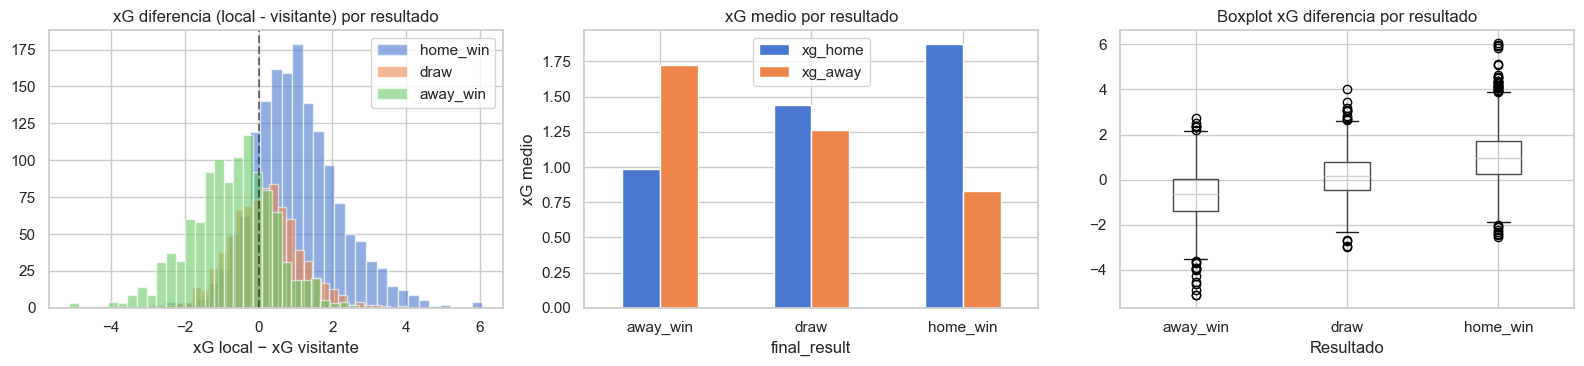

In [12]:
# xG acumulado por partido y equipo
shots = df[df["xg"].notna()].copy()
xg_match = shots.groupby(["match_id", "is_home", "final_result"])["xg"].sum().reset_index()
xg_home = xg_match[xg_match["is_home"] == True].rename(columns={"xg": "xg_home"})
xg_away = xg_match[xg_match["is_home"] == False].rename(columns={"xg": "xg_away"})
xg_per_match = xg_home.merge(xg_away[["match_id", "xg_away"]], on="match_id")
xg_per_match["xg_diff"] = xg_per_match["xg_home"] - xg_per_match["xg_away"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución xG por resultado
for result in ["home_win", "draw", "away_win"]:
    subset = xg_per_match[xg_per_match["final_result"] == result]["xg_diff"]
    axes[0].hist(subset, bins=30, alpha=0.6, label=result)
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("xG diferencia (local - visitante) por resultado")
axes[0].set_xlabel("xG local − xG visitante")
axes[0].legend()

# xG medio por resultado
xg_per_match.groupby("final_result")[["xg_home", "xg_away"]].mean().plot(
    kind="bar", ax=axes[1], rot=0
)
axes[1].set_title("xG medio por resultado")
axes[1].set_ylabel("xG medio")

# Boxplot xG diferencia
xg_per_match.boxplot(column="xg_diff", by="final_result", ax=axes[2])
axes[2].set_title("Boxplot xG diferencia por resultado")
axes[2].set_xlabel("Resultado")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [13]:
shots = df[df["xg"].notna()].copy()

print(f"xG medio por tiro: {shots['xg'].mean():.3f}")

xg_match = shots.groupby(["match_id", "is_home"])["xg"].sum().unstack()
xg_match.columns = ["xg_away", "xg_home"]
print(f"xG medio por partido — local: {xg_match['xg_home'].mean():.2f}, visitante: {xg_match['xg_away'].mean():.2f}")

goals_90 = df[(df["event_type"] == "Shot") & (df["shot_outcome"] == "Goal") & (df["minute"] <= 90)]
total_shots = df[df["event_type"] == "Shot"]
print(f"Tasa de conversión (goles ≤90 min / tiros totales): {len(goals_90) / len(total_shots) * 100:.1f}%")

print("\nOutcomes de tiros:")
print(df[df["event_type"] == "Shot"]["shot_outcome"].value_counts().to_frame("tiros"))

xG medio por tiro: 0.107
xG medio por partido — local: 1.49, visitante: 1.22


Tasa de conversión (goles ≤90 min / tiros totales): 10.4%

Outcomes de tiros:
                  tiros
shot_outcome           
Off T             28466
Blocked           21677
Saved             20788
Goal               9790
Wayward            4823
Post               1842
Saved Off Target    349
Saved to Post       288


### 5a. Tasa de pases completados por resultado

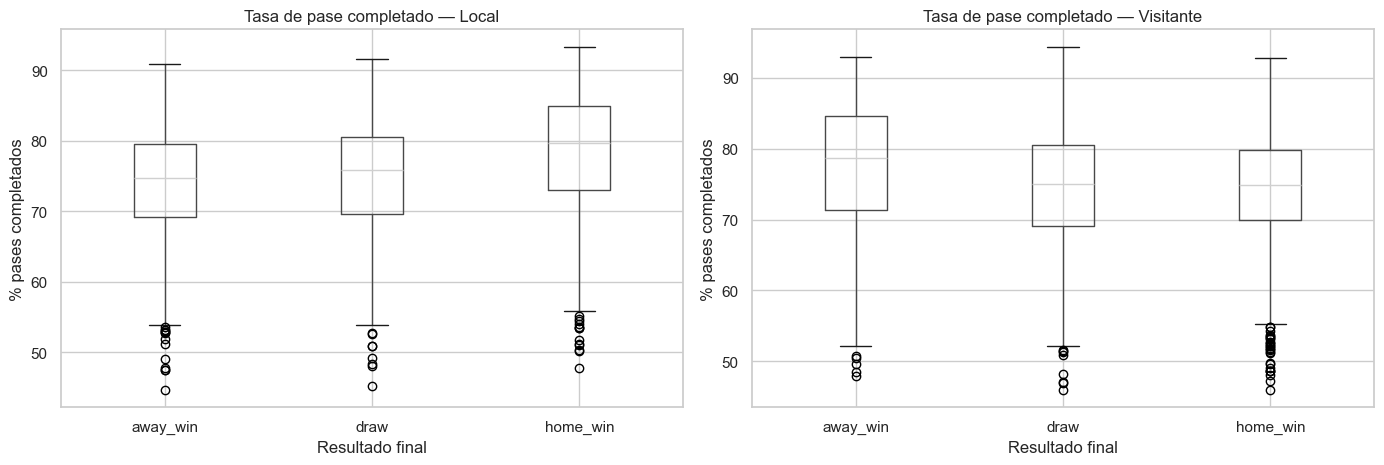

is_home       False  True 
final_result              
away_win      77.43  73.98
draw          74.41  74.88
home_win      74.32  78.57


In [14]:
passes = df[df["event_type"] == "Pass"].copy()
passes["completed"] = passes["pass_outcome"] == "Complete"

pass_stats = passes.groupby(["match_id", "is_home", "final_result"]).agg(
    total=("completed", "count"),
    completed_n=("completed", "sum"),
).reset_index()
pass_stats["completion_rate"] = pass_stats["completed_n"] / pass_stats["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, is_home, label in zip(axes, [True, False], ["Local", "Visitante"]):
    data = pass_stats[pass_stats["is_home"] == is_home]
    data.boxplot(column="completion_rate", by="final_result", ax=ax)
    ax.set_title(f"Tasa de pase completado — {label}")
    ax.set_xlabel("Resultado final")
    ax.set_ylabel("% pases completados")
    plt.sca(ax)
    plt.title(f"Tasa de pase completado — {label}")

plt.suptitle("")
plt.tight_layout()
plt.show()

print(pass_stats.groupby(["final_result", "is_home"])["completion_rate"].mean().round(2).unstack())

### 5b. Goles reales por partido

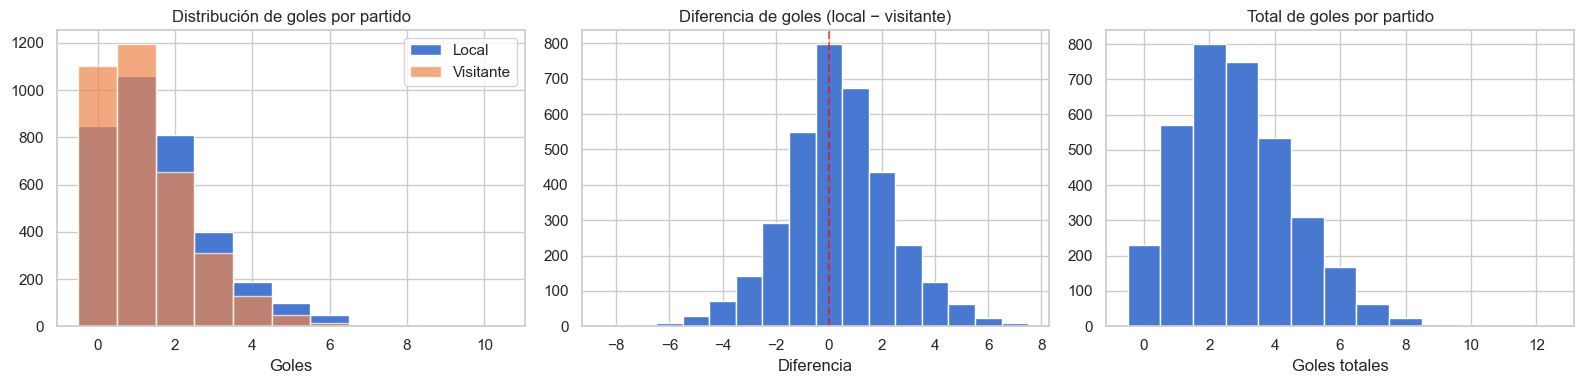

       final_score_home  final_score_away  total_goals  goal_diff
count           3464.00           3464.00      3464.00    3464.00
mean               1.60              1.26         2.85       0.34
std                1.45              1.26         1.75       2.09
min                0.00              0.00         0.00      -9.00
25%                1.00              0.00         2.00      -1.00
50%                1.00              1.00         3.00       0.00
75%                2.00              2.00         4.00       2.00
max               13.00              9.00        13.00      13.00

Partidos con diferencia de 1 gol: 1224 (35.3%)
Partidos 0-0: 231
Partidos decididos por 1 gol: 35.3%
Partidos 0-0: 231


In [15]:
score_df = df.drop_duplicates("match_id")[["match_id", "final_score_home", "final_score_away", "final_result"]].copy()
score_df["goal_diff"] = score_df["final_score_home"] - score_df["final_score_away"]
score_df["total_goals"] = score_df["final_score_home"] + score_df["final_score_away"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(score_df["final_score_home"], bins=range(0, 12), align="left", edgecolor="white", label="Local")
axes[0].hist(score_df["final_score_away"], bins=range(0, 12), align="left", edgecolor="white", alpha=0.7, label="Visitante")
axes[0].set_title("Distribución de goles por partido")
axes[0].set_xlabel("Goles")
axes[0].legend()

axes[1].hist(score_df["goal_diff"], bins=range(-8, 9), align="left", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", alpha=0.6)
axes[1].set_title("Diferencia de goles (local − visitante)")
axes[1].set_xlabel("Diferencia")

axes[2].hist(score_df["total_goals"], bins=range(0, 14), align="left", edgecolor="white")
axes[2].set_title("Total de goles por partido")
axes[2].set_xlabel("Goles totales")

plt.tight_layout()
plt.show()

print(score_df[["final_score_home", "final_score_away", "total_goals", "goal_diff"]].describe().round(2))
print(f"\nPartidos con diferencia de 1 gol: {(score_df['goal_diff'].abs() == 1).sum()} ({(score_df['goal_diff'].abs() == 1).mean()*100:.1f}%)")
print(f"Partidos 0-0: {(score_df['total_goals'] == 0).sum()}")

one_goal = (score_df["goal_diff"].abs() == 1).mean() * 100
zero_zero = ((score_df["final_score_home"] == 0) & (score_df["final_score_away"] == 0)).sum()
print(f"Partidos decididos por 1 gol: {one_goal:.1f}%")
print(f"Partidos 0-0: {zero_zero}")


### 5c. Correlación de features vs resultado

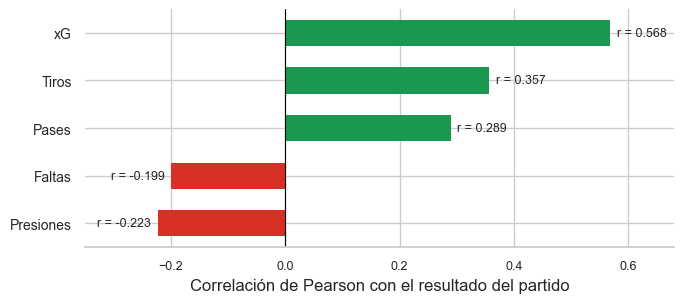

In [16]:
# Correlación de métricas con el resultado del partido
import pandas as pd

agg = df.groupby(["match_id", "is_home", "final_result"]).agg(
    shots    =("event_type", lambda x: (x == "Shot").sum()),
    xg       =("xg", "sum"),
    passes   =("event_type", lambda x: (x == "Pass").sum()),
    pressures=("event_type", lambda x: (x == "Pressure").sum()),
    fouls    =("event_type", lambda x: (x == "Foul Committed").sum()),
).reset_index()

home = agg[agg["is_home"] == True].drop(columns="is_home")
away = agg[agg["is_home"] == False].drop(columns="is_home")
match_agg = home.merge(away, on=["match_id", "final_result"], suffixes=("_home", "_away"))

for col in ["shots", "xg", "passes", "pressures", "fouls"]:
    match_agg[f"diff_{col}"] = match_agg[f"{col}_home"] - match_agg[f"{col}_away"]

result_map = {"home_win": 1, "draw": 0, "away_win": -1}
match_agg["result_num"] = match_agg["final_result"].map(result_map)

diff_cols = [c for c in match_agg.columns if c.startswith("diff_")]
corr = match_agg[diff_cols + ["result_num"]].corr()["result_num"].drop("result_num").sort_values()

labels = {
    "diff_xg":        "xG",
    "diff_shots":     "Tiros",
    "diff_passes":    "Pases",
    "diff_fouls":     "Faltas",
    "diff_pressures": "Presiones",
}
corr.index = [labels.get(i, i) for i in corr.index]

fig, ax = plt.subplots(figsize=(7, 3.2))
colors = ["#d73027" if v < 0 else "#1a9850" for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors, edgecolor="none", height=0.55)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con el resultado del partido")
ax.set_xlim(-0.35, 0.68)
for bar, v in zip(bars, corr.values):
    ax.text(v + (0.012 if v >= 0 else -0.012), bar.get_y() + bar.get_height() / 2,
            f"r = {v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.savefig("../assets/figuras/eda/correlacion_features.pdf", bbox_inches="tight")
plt.show()


### 5d. Análisis de presiones

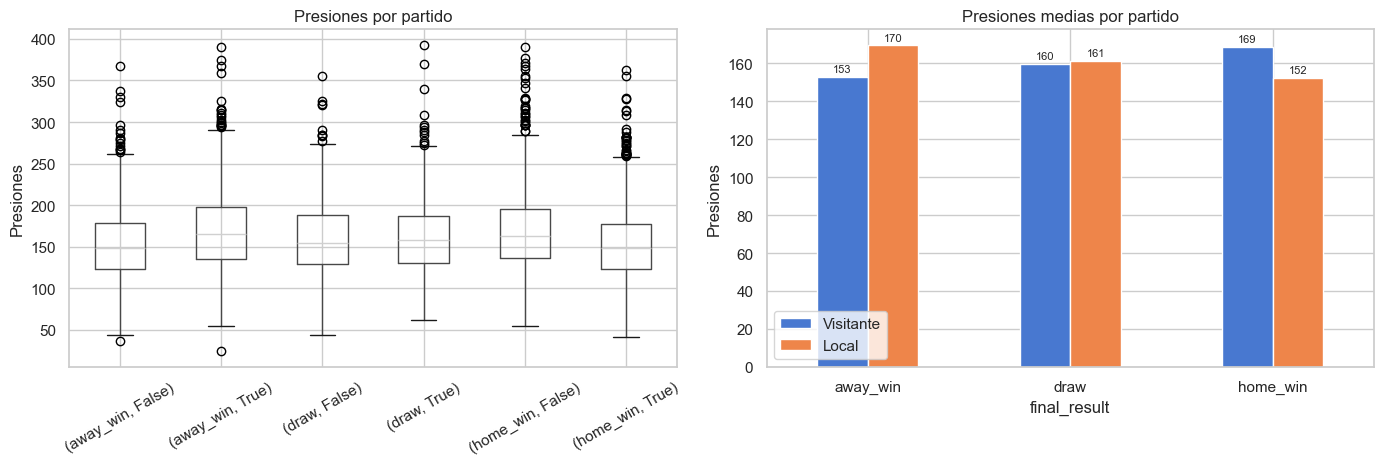

              Visitante  Local
final_result                  
away_win          153.0  169.5
draw              159.6  161.3
home_win          168.8  152.3


In [17]:
pres = (df[df["event_type"] == "Pressure"]
        .groupby(["match_id", "is_home", "final_result"])
        .size()
        .reset_index(name="pressures"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pres.boxplot(column="pressures", by=["final_result", "is_home"], ax=axes[0], rot=30)
axes[0].set_title("Presiones por partido según resultado y localía")
axes[0].set_xlabel("")
axes[0].set_ylabel("Presiones")
plt.sca(axes[0])
plt.title("Presiones por partido")

mean_pres = pres.groupby(["final_result", "is_home"])["pressures"].mean().round(1).unstack()
mean_pres.columns = ["Visitante", "Local"]
mean_pres.plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Presiones medias por partido")
axes[1].set_ylabel("Presiones")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=2, fontsize=8)

plt.suptitle("")
plt.tight_layout()
plt.show()

print(mean_pres)

## 6. Marcador en curso

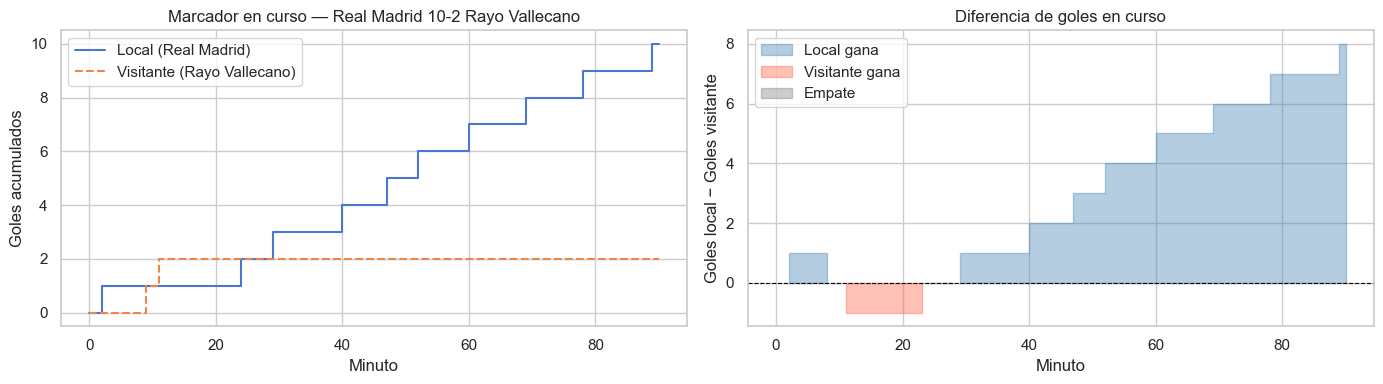


Total goles derivables en el dataset: 9,790
La derivación del marcador en curso es viable para todos los partidos.


In [18]:
def get_running_score(match_df):
    """Devuelve el marcador acumulado minuto a minuto para un partido."""
    goals = (match_df[(match_df["event_type"] == "Shot") &
                      (match_df["shot_outcome"] == "Goal") &
                      (match_df["minute"] <= 90)]
             .sort_values("minute")[["minute", "is_home"]])

    score = pd.DataFrame({"minute": range(0, 91)})
    score["goals_home"] = 0
    score["goals_away"] = 0
    for _, g in goals.iterrows():
        col = "goals_home" if g["is_home"] else "goals_away"
        score.loc[score["minute"] >= g["minute"], col] += 1
    score["score_diff"] = score["goals_home"] - score["goals_away"]
    return score

# Partido de ejemplo con varios goles
sample_id = (df[(df["event_type"] == "Shot") & (df["shot_outcome"] == "Goal") &
                (df["minute"] <= 90)]
             .groupby("match_id").size()
             .nlargest(5).index[2])

match_df = df[df["match_id"] == sample_id]
info = match_df[["home_team","away_team","final_score_home","final_score_away","final_result"]].iloc[0]
score = get_running_score(match_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].step(score["minute"], score["goals_home"], label=f"Local ({info['home_team']})", where="post")
axes[0].step(score["minute"], score["goals_away"], label=f"Visitante ({info['away_team']})", where="post", linestyle="--")
axes[0].set_title(f"Marcador en curso — {info['home_team']} {int(info['final_score_home'])}-{int(info['final_score_away'])} {info['away_team']}")
axes[0].set_xlabel("Minuto")
axes[0].set_ylabel("Goles acumulados")
axes[0].legend()

axes[1].fill_between(score["minute"], score["score_diff"], step="post",
                     where=(score["score_diff"] > 0), alpha=0.4, color="steelblue", label="Local gana")
axes[1].fill_between(score["minute"], score["score_diff"], step="post",
                     where=(score["score_diff"] < 0), alpha=0.4, color="tomato", label="Visitante gana")
axes[1].fill_between(score["minute"], score["score_diff"], step="post",
                     where=(score["score_diff"] == 0), alpha=0.4, color="gray", label="Empate")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Diferencia de goles en curso")
axes[1].set_xlabel("Minuto")
axes[1].set_ylabel("Goles local − Goles visitante")
axes[1].legend()

plt.tight_layout()
plt.savefig("../assets/figuras/eda/marcador_en_curso.pdf", bbox_inches="tight")
plt.show()

print(f"\nTotal goles derivables en el dataset: {len(df[(df['event_type']=='Shot') & (df['shot_outcome']=='Goal')]):,}")
print("La derivación del marcador en curso es viable para todos los partidos.")

## 7. Calidad de los datos

In [19]:
null_pct = df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
null_df = null_pct[null_pct > 0].rename("% nulos").to_frame()
null_df["esperado"] = null_df.index.isin([
    "xg", "shot_outcome", "pass_outcome", "pass_length", "pass_angle",
    "dribble_outcome", "carry_length", "duel_type", "duel_outcome",
    "interception_outcome", "card_type", "loc_x", "loc_y"
])
null_df

,% nulos,esperado
card_type,99.88,True
interception_outcome,99.35,True
xg,99.28,True
shot_outcome,99.28,True
dribble_outcome,99.00,True
duel_outcome,98.90,True
duel_type,97.88,True
carry_length,78.40,True
pass_length,72.21,True
pass_angle,72.21,True
